<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/OIBSIP/blob/main/OIBSIP_Datascience_Task_2_advertising_sales_prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advertising Sales Prediction: Model Training and Evaluation

This notebook aims to analyze the impact of different advertising channels (TV, Radio, Newspaper) on sales. We will perform Exploratory Data Analysis (EDA), train both Linear Regression and Polynomial Regression models, evaluate their performance, and interpret the results to understand which advertising channel has the highest impact on sales.

This notebook aims to analyze the impact of different advertising channels (TV, Radio, Newspaper) on sales. We will perform Exploratory Data Analysis (EDA), train both Linear Regression and Polynomial Regression models, evaluate their performance, and interpret the results to understand which advertising channel has the highest impact on sales.

## 1. Setup and Data Loading

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:

df = pd.read_csv('/content/Advertising.csv')


print('First 5 rows of the DataFrame:')
display(df.head())

First 5 rows of the DataFrame:


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 2. Initial Data Inspection

Before diving into analysis, we'll perform basic checks like looking for missing values and examining descriptive statistics.

In [28]:

print('\nNull values in each column:')
display(df.isnull().sum())


Null values in each column:


,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [29]:

print('\nDescriptive statistics:')
display(df.describe())


Descriptive statistics:


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 3. Exploratory Data Analysis (EDA) and Visualization

Visualizing the data helps us understand distributions, relationships between variables, and potential patterns.

### Pairplot of All Features

A pairplot shows scatter plots for all pairs of variables and histograms/KDEs for individual variables, revealing overall distributions and relationships.


Pairplot of all features:


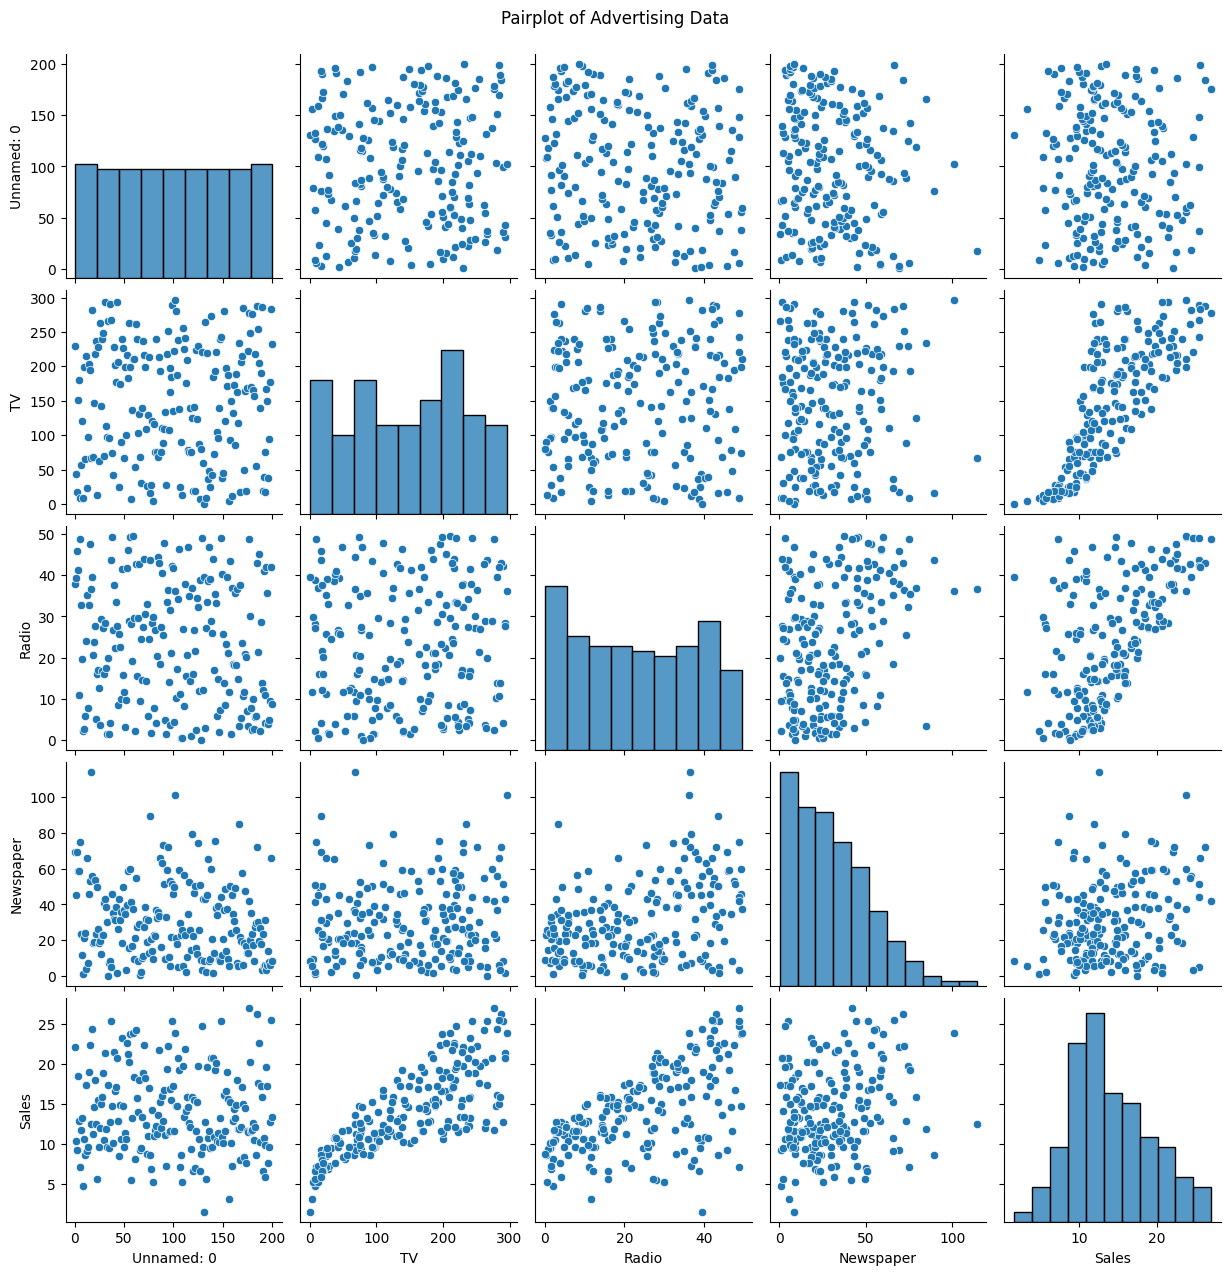

In [30]:

print('\nPairplot of all features:')
sns.pairplot(df)
plt.suptitle('Pairplot of Advertising Data', y=1.02)
plt.show()

### Individual Scatter Plots: Sales vs. Advertising Spend

These plots help visualize the direct relationship between each advertising channel and sales.

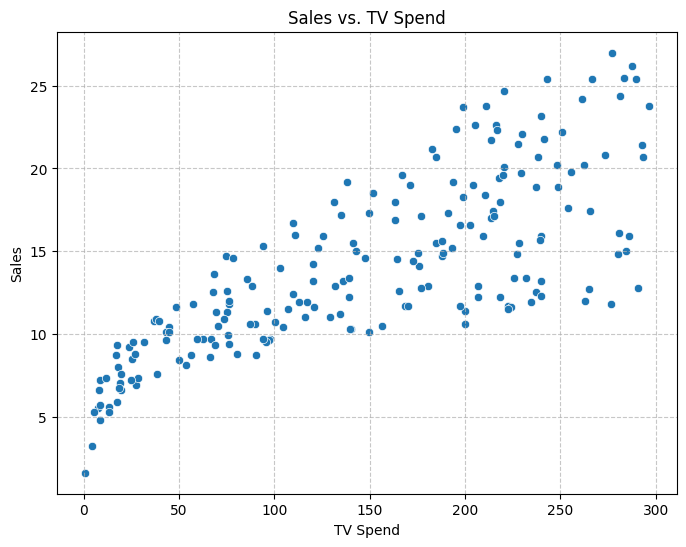

In [31]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('Sales vs. TV Spend')
plt.xlabel('TV Spend')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

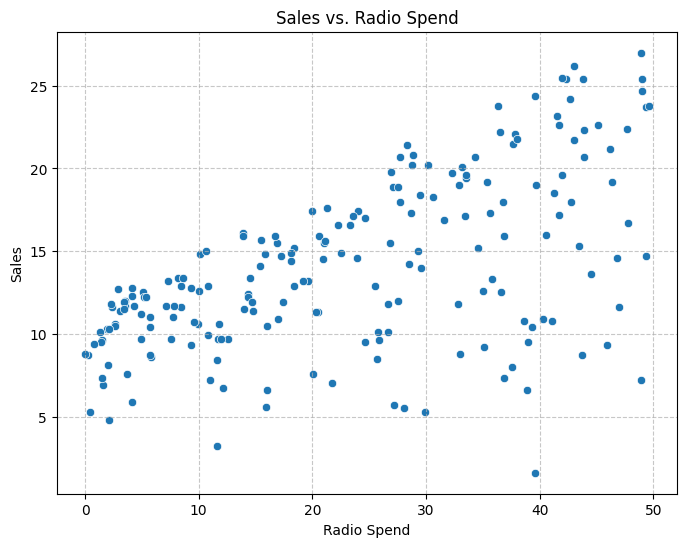

In [32]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Sales vs. Radio Spend')
plt.xlabel('Radio Spend')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

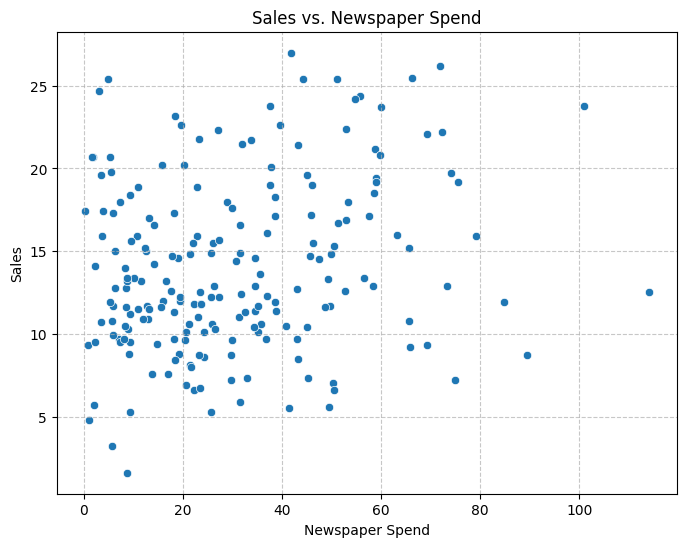

In [33]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Sales vs. Newspaper Spend')
plt.xlabel('Newspaper Spend')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlation Matrix Heatmap

A heatmap visualizes the correlation coefficients between all pairs of variables, showing strength and direction of relationships.


Correlation Matrix Heatmap:


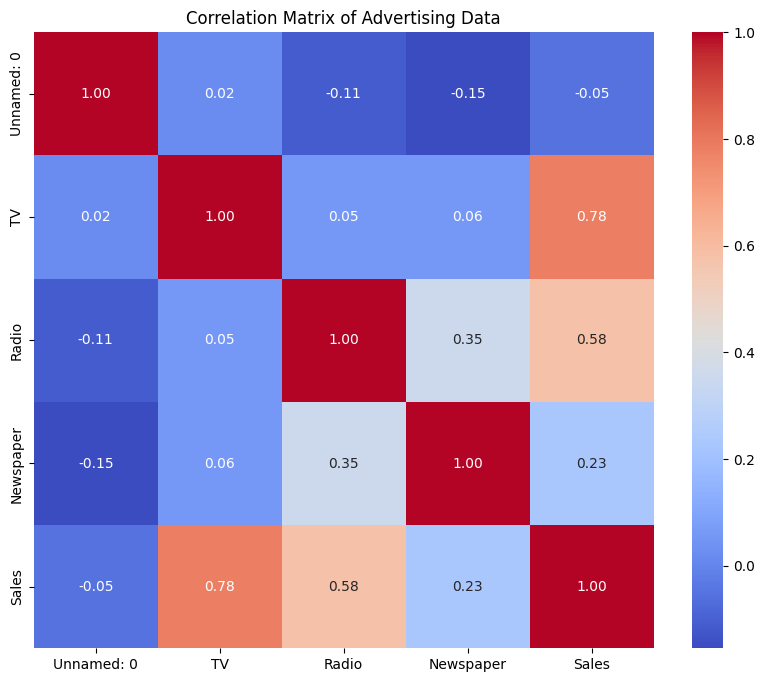

In [34]:

print('\nCorrelation Matrix Heatmap:')
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Advertising Data')
plt.show()

## 4. Data Preprocessing: Train-Test Split

We split the data into training and testing sets to evaluate our models on unseen data. 'Sales' will be our target variable (`y`), and 'TV', 'Radio', 'Newspaper' will be our features (`X`).

In [41]:

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)


X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)


display(X_train.head())

Shape of X_train: (160, 3)
Shape of X_test: (40, 3)
Shape of y_train: (160,)
Shape of y_test: (40,)


,TV,Radio,Newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6


## 5. Model Training

We will train two regression models: a simple Linear Regression model as a baseline and a Polynomial Regression model to capture potential non-linear relationships.

### Linear Regression Model (Baseline)

Linear regression assumes a linear relationship between the independent variables and the dependent variable.

In [36]:

linear_model = LinearRegression()


linear_model.fit(X_train, y_train)


print('Linear Regression Intercept:', linear_model.intercept_)
print('Linear Regression Coefficients (TV, Radio, Newspaper):', linear_model.coef_)

Linear Regression Intercept: 2.979067338122629
Linear Regression Coefficients (TV, Radio, Newspaper): [0.04472952 0.18919505 0.00276111]


### Polynomial Regression Model (Degree 2)

Polynomial Regression allows us to model non-linear relationships by transforming original features into polynomial features (e.g., squaring them) and then fitting a linear model to these transformed features. We will use a degree 2 polynomial.

In [37]:

poly_features = PolynomialFeatures(degree=2)


X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


print('Polynomial Regression Intercept:', poly_model.intercept_)
print('Polynomial Regression Coefficients:', poly_model.coef_)

Polynomial Regression Intercept: 4.939014879989298
Polynomial Regression Coefficients: [ 0.00000000e+00  5.32356160e-02  1.70980451e-02  1.05807447e-02
 -1.12286779e-04  1.11121741e-03 -7.37989541e-05  1.32842962e-04
  1.24892479e-04  2.79665560e-05]


## 6. Model Evaluation

We will evaluate both models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R2 Score to understand their performance on the test set.

### Linear Regression Model Evaluation

In [38]:

linear_predictions = linear_model.predict(X_test)


linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print(f"Linear Regression MAE: {linear_mae:.3f}")
print(f"Linear Regression RMSE: {linear_rmse:.3f}")
print(f"Linear Regression R2 Score: {linear_r2:.3f}")

Linear Regression MAE: 1.461
Linear Regression RMSE: 1.782
Linear Regression R2 Score: 0.899


### Polynomial Regression Model Evaluation

In [39]:

poly_predictions = poly_model.predict(X_test_poly)


poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_predictions))
poly_r2 = r2_score(y_test, poly_predictions)

print(f"Polynomial Regression MAE: {poly_mae:.3f}")
print(f"Polynomial Regression RMSE: {poly_rmse:.3f}")
print(f"Polynomial Regression R2 Score: {poly_r2:.3f}")

Polynomial Regression MAE: 0.526
Polynomial Regression RMSE: 0.643
Polynomial Regression R2 Score: 0.987


### Model Comparison Summary

| Metric | Linear Regression | Polynomial Regression (Degree 2) |
|---|---|---|
| MAE | 1.461 | 0.526 |
| RMSE | 1.782 | 0.643 |
| R2 Score | 0.899 | 0.987 |

From the comparison, the **Polynomial Regression model (Degree 2) significantly outperforms the Linear Regression model** across all metrics, indicating a much better fit to the data with lower errors and a higher variance explained. This suggests that there are indeed non-linear relationships between advertising spend and sales.

## 7. Residual Analysis for the Best Model

We will create a residual plot for the Polynomial Regression model (our best model) to check if the errors are randomly distributed or exhibit any systematic patterns.

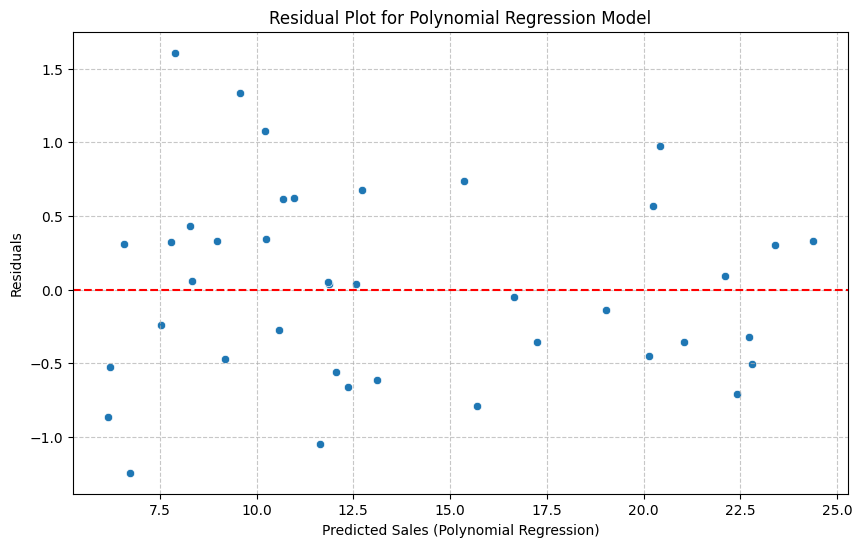

In [40]:

poly_residuals = y_test - poly_predictions


plt.figure(figsize=(10, 6))
sns.scatterplot(x=poly_predictions, y=poly_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales (Polynomial Regression)')
plt.ylabel('Residuals')
plt.title('Residual Plot for Polynomial Regression Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretation of the Residual Plot

The residual plot shows the difference between the actual and predicted values. Ideally, residuals should be randomly scattered around zero. The plot for the Polynomial Regression model shows:

*   **Randomly Distributed Errors:** The points appear to be scattered randomly around the horizontal line at zero, with no obvious patterns (e.g., no clear curve, funnel shape, or distinct clusters). This suggests that the Polynomial Regression model (with degree 2) has captured most of the underlying patterns in the data, and its errors are largely random.
*   **No Systematic Biases:** The lack of a discernible pattern indicates that the model is not systematically over-predicting or under-predicting sales for certain ranges of predicted values. This is a good sign for the model's reliability.

## 8. Interpretation: Which Advertising Channel Has the Highest Impact on Sales?

Based on the coefficients from the **Linear Regression model**, which directly show the linear impact of each feature on the target, we can interpret the influence of each advertising channel:

*   **Radio:** With a coefficient of approximately **0.189**, Radio advertising has the highest positive impact on sales. This means that for every unit increase in Radio advertising spend, sales are predicted to increase by about 0.189 units, assuming other advertising efforts remain constant.

*   **TV:** The coefficient for TV advertising is approximately **0.045**. This indicates a positive but lower impact compared to Radio. For every unit increase in TV advertising spend, sales are predicted to increase by about 0.045 units.

*   **Newspaper:** The coefficient for Newspaper advertising is very small, approximately **0.003**. This suggests a very small positive impact, almost negligible, on sales compared to TV and Radio.

Therefore, according to the linear model, **Radio advertising has the highest impact on sales**.